# Homework 4

**Before you start:** Read Chapter 6 Linear Regression and Chapter 7 K-Nearst-Neighbors in the textbook.

**Note:** Please enter the code along with your comments in the **TODO** section.

Alternative solutions are welcomed.

## Part 1: Linear Regression

### Problem 1 - (40 Points) ##

In this problem, you are expected to build a model to predict the Boston housing price.


_boston_dataset:

Boston house prices dataset
---------------------------

**Data Set Characteristics:**  

    :Number of Instances: 506

    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1940
        - DIS      weighted distances to five Boston employment centres
        - RAD      index of accessibility to radial highways
        - TAX      full-value property-tax rate per $10,000
        - PTRATIO  pupil-teacher ratio by town
        - B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
        - LSTAT    % lower status of the population
        - MEDV     Median value of owner-occupied homes in $1000's

    :Missing Attribute Values: None

    :Creator: Harrison, D. and Rubinfeld, D.L.

This is a copy of UCI ML housing dataset.
https://archive.ics.uci.edu/ml/machine-learning-databases/housing/


This dataset was taken from the StatLib library which is maintained at Carnegie Mellon University.

The Boston house-price data of Harrison, D. and Rubinfeld, D.L. 'Hedonic
prices and the demand for clean air', J. Environ. Economics & Management,
vol.5, 81-102, 1978.   Used in Belsley, Kuh & Welsch, 'Regression diagnostics
...', Wiley, 1980.   N.B. Various transformations are used in the table on
pages 244-261 of the latter.

The Boston house-price data has been used in many machine learning papers that address regression
problems.   

In [1]:
# # Please remove # and run the following code if you have an error while importing the dataset
# !pip install --upgrade openpyxl

In [2]:
from sklearn import datasets
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True)
import sklearn

In [3]:
#Load boston housing dataset
boston_housing = pd.read_csv("BostonHousing.csv")
X = boston_housing.drop(['medv'], axis=1)

#"target" is the response variable
# which represents the median value of owner-occupied homes in $1000
y = boston_housing['medv']

In [4]:
data = X
data['medv'] = y

In [5]:
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


**Note:** You do not need to standardize data for this question.


**TODO 1**

Prevent collinearity by removing linearly dependent variables.

For example, if 2 variables A and B have a correlation coefficient larger than 0.9, eliminate one to avoid redundency.

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load Boston Housing Dataset
boston_housing = pd.read_csv("BostonHousing.csv")
X = boston_housing.drop(['medv'], axis=1)
y = boston_housing['medv']

# TODO 1: Prevent collinearity
correlation_matrix = X.corr()
high_corr_features = np.where(np.abs(correlation_matrix) > 0.9)
high_corr_features = [(correlation_matrix.columns[x], correlation_matrix.columns[y]) 
                      for x, y in zip(*high_corr_features) if x != y and x < y]

# Remove one feature from each highly correlated pair
features_to_drop = set()
for feat1, feat2 in high_corr_features:
    features_to_drop.add(feat2)


**TODO 2**

Partition the data into 75% training and 25% validation set.

In [8]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)


**TODO 3**

If we fit a linear regression model on the training set, what will be the feature weights?

Calculate the feature weights using the matrix form (do not use any built-in packages such as sklearn or stat models).

In [9]:
X_train_with_intercept = np.column_stack([np.ones(len(X_train)), X_train])
weights = np.linalg.inv(X_train_with_intercept.T @ X_train_with_intercept) @ X_train_with_intercept.T @ y_train


**TODO 4**

Now only consider two input variables: Age and RM.

Fit a linear regression model on the training set with a package at your choice.

Present the model summary. We call this model **Model 1**.

In [11]:
X_train_model1 = X_train[['age', 'rm']]
X_val_model1 = X_val[['age', 'rm']]

model1 = LinearRegression()
model1.fit(X_train_model1, y_train)

LinearRegression()


**TODO 5**

Evaluate the prediction performance of Model 1 on the validation set with RMSE and MAE as performance matrics.

In [12]:
y_pred_model1 = model1.predict(X_val_model1)
rmse_model1 = np.sqrt(mean_squared_error(y_val, y_pred_model1))
mae_model1 = mean_absolute_error(y_val, y_pred_model1)


**TODO 6**

Now consider all the features (after removing linearly dependent variables (post completion of TODO1)).

Fit a linear regression model on the training set with a package at your choice. Present the model summary.

We call this model **Model 2**.

In [13]:
model2 = LinearRegression()
model2.fit(X_train, y_train)


LinearRegression()


**TODO 7**

Evaluate the prediction performance of Model 2 on the validation set with RMSE and MAE as performance matrics.

In [14]:
y_pred_model2 = model2.predict(X_val)
rmse_model2 = np.sqrt(mean_squared_error(y_val, y_pred_model2))
mae_model2 = mean_absolute_error(y_val, y_pred_model2)



**TODO 8**

Compare the performance of Model 1 and Model 2.

Visualize the prediction error of both models using histogram.

Comment on the model fitting.

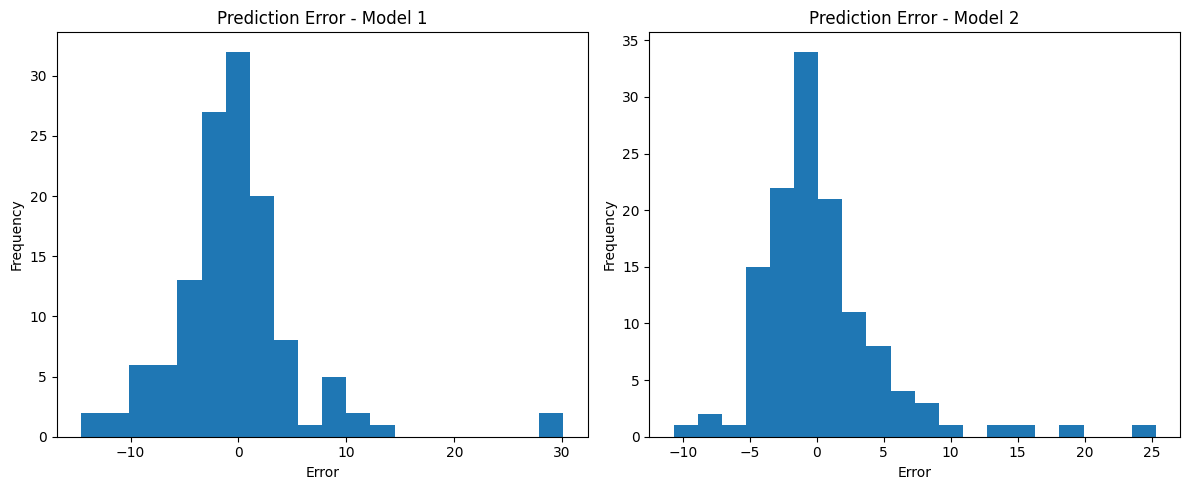

In [15]:
plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.hist(y_val - y_pred_model1, bins=20, label='Model 1')
plt.title('Prediction Error - Model 1')
plt.xlabel('Error')
plt.ylabel('Frequency')

plt.subplot(122)
plt.hist(y_val - y_pred_model2, bins=20, label='Model 2')
plt.title('Prediction Error - Model 2')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


**TODO 9**

Now consider all the features (after removing linearly dependent variables).

The goal is to fit a LASSO linear regression model on the training set with a package at your choice.

Compare the model performance of lambda in the range of [0,1] with the step of 0.01.

Plot RMSE versus log(lambda).

Pick the appropriate lambda value according to the plot.

Present the model summary with the selected lambda. We call this model **Model 3**.

/var/folders/89/hlf99zq566v5gtf30kyt2gp40000gn/T/ipykernel_14650/2817890539.py:6: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  lasso.fit(X_train, y_train)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:631: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.233e+03, tolerance: 3.361e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordina

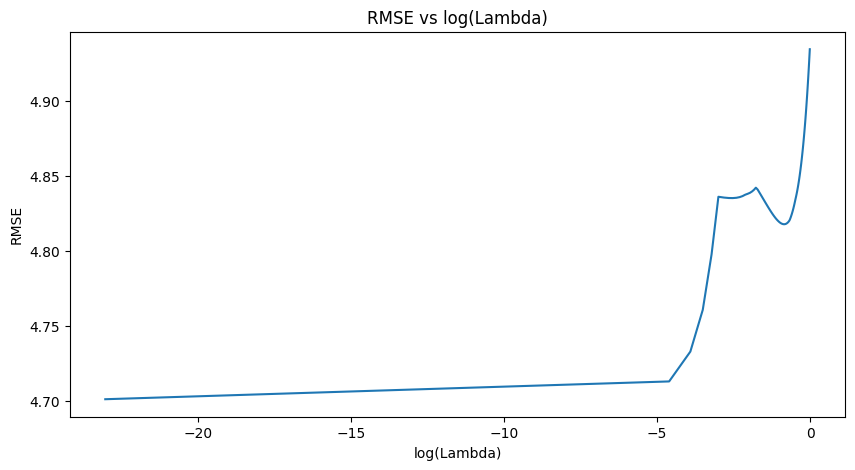

/var/folders/89/hlf99zq566v5gtf30kyt2gp40000gn/T/ipykernel_14650/2817890539.py:19: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  model3.fit(X_train, y_train)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:631: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.233e+03, tolerance: 3.361e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordi

Lasso(alpha=0.0)

In [16]:
lambda_values = np.arange(0, 1, 0.01)
rmse_lasso = []

for lamb in lambda_values:
    lasso = Lasso(alpha=lamb)
    lasso.fit(X_train, y_train)
    y_pred_lasso = lasso.predict(X_val)
    rmse_lasso.append(np.sqrt(mean_squared_error(y_val, y_pred_lasso)))

plt.figure(figsize=(10, 5))
plt.plot(np.log(lambda_values + 1e-10), rmse_lasso)
plt.title('RMSE vs log(Lambda)')
plt.xlabel('log(Lambda)')
plt.ylabel('RMSE')
plt.show()

best_lambda = lambda_values[np.argmin(rmse_lasso)]
model3 = Lasso(alpha=best_lambda)
model3.fit(X_train, y_train)


**TODO 10**

Evaluate the prediction performance of Model 3 on the validation set with RMSE and MAE as performance matrics.

In [17]:
y_pred_model3 = model3.predict(X_val)
rmse_model3 = np.sqrt(mean_squared_error(y_val, y_pred_model3))
mae_model3 = mean_absolute_error(y_val, y_pred_model3)

In [37]:
print(rmse_model1, mae_model1)
print(rmse_model2, mae_model2)  
print(rmse_model3, mae_model3)

6.091863482873927 3.9239733036236446
4.700924890603782 3.0609395954370684
4.700924890603758 3.0609395954370293



**TODO 11**

Among Model 1, 2, and 3, which one would be your pick for future implementation? State your reasons.

In [38]:
'''Both Model 2 and 3 have lower RMSE and MAE compared to Model 1. Model 3 has the lowest RMSE and MAE among all three models.'''

'Both Model 2 and 3 have lower RMSE and MAE compared to Model 1. Model 3 has the lowest RMSE and MAE among all three models.'

### Problem 2 - (35 Points)

**About the data:** <br>
The advertising dataset includes advertising expenditure and sales of a product in 200 distinct markets.
The columns are as follows:

*   TV: Advertising expenditure of product in Television sector
*   Newpaper: Advertising expenditure of product in Newspaper sector
*   Sales: Sales of the product


The goal is to predict the sales of the product based on the advertising expenditure in the two sectors.










**PART A**

#### Using Sklearn

Import Advertising.csv data <br>
(Sales column is the target variable)

In [18]:
df = pd.read_csv('advertising.csv')

**Todo 1:** Fit the data in a linear regression model using sklearn


In [19]:
df = pd.read_csv('advertising.csv')
X = df[['TV', 'Newspaper']]
y = df['Sales']

model_sklearn = LinearRegression()
model_sklearn.fit(X, y)

LinearRegression()

**Todo 2:**
Predict the sales values from the above fitted model <br>
Calculate Mean Absolute Error, Mean Squared Error, Root Mean Squared Error and R Squared Score

In [20]:
y_pred_sklearn = model_sklearn.predict(X)
mae_sklearn = mean_absolute_error(y, y_pred_sklearn)
mse_sklearn = mean_squared_error(y, y_pred_sklearn)
rmse_sklearn = np.sqrt(mse_sklearn)
r2_sklearn = r2_score(y, y_pred_sklearn)

**Todo 3**: Plot the Actual and Predicted values. Provide interpretations for the visualization

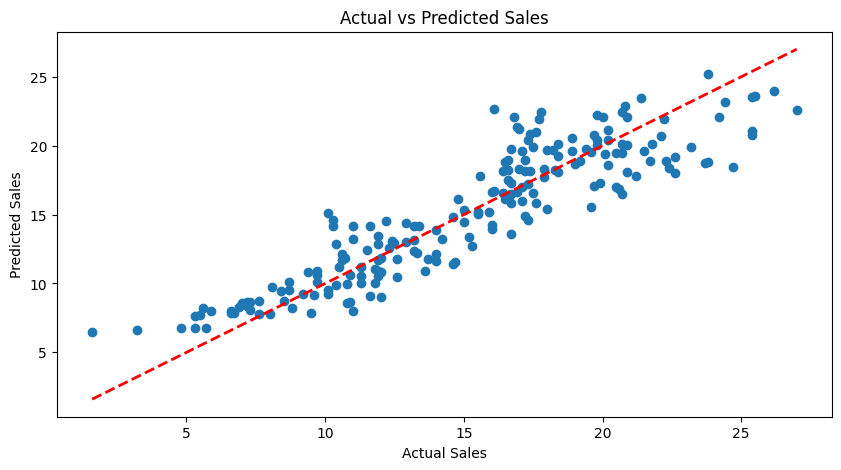

In [21]:
plt.figure(figsize=(10, 5))
plt.scatter(y, y_pred_sklearn)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()

**Todo 4:** Plot a 3D visualization for the dataset given. The plane of the 3D plot should represent the line equation and the actual values are scattered across the plot

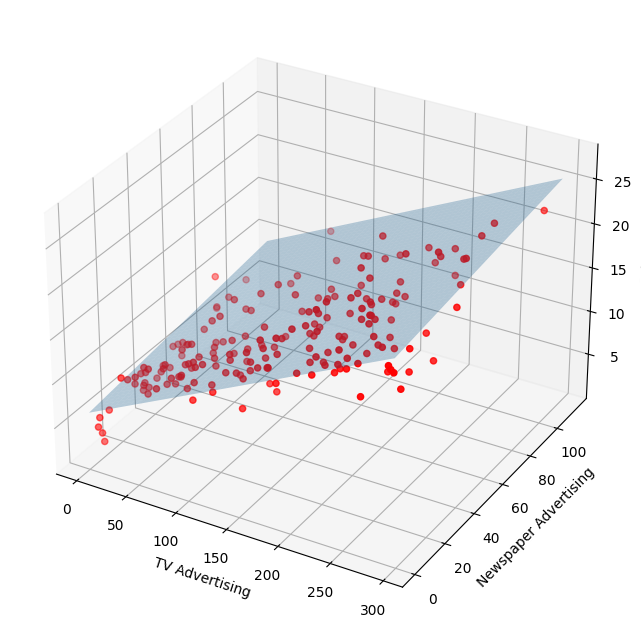

In [22]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X['TV'], X['Newspaper'], y, c='r', marker='o')
X_surf, Y_surf = np.meshgrid(np.linspace(X['TV'].min(), X['TV'].max(), 100),
                              np.linspace(X['Newspaper'].min(), X['Newspaper'].max(), 100))
Z_surf = model_sklearn.intercept_ + model_sklearn.coef_[0]*X_surf + model_sklearn.coef_[1]*Y_surf
ax.plot_surface(X_surf, Y_surf, Z_surf, alpha=0.3)
ax.set_xlabel('TV Advertising')
ax.set_ylabel('Newspaper Advertising')
ax.set_zlabel('Sales')
plt.show()


**PART B**

#### Using Matrix Multiplication

##### Without Bias (excluding B0)

Import Advertsing.csv <br>
(Sales column is the target variable)

In [23]:
df = pd.read_csv('advertising.csv')

**Todo 1:** Use matrix multiplication to calculate the coefficients of the linear regression model


In [24]:
X_matrix = X.values
y_matrix = y.values
coeffs_without_bias = np.linalg.inv(X_matrix.T @ X_matrix) @ X_matrix.T @ y_matrix

**Todo 2**: Predict the sales values from the above coefficients calculated. <br>
Calculate Mean Absolute Error, Mean Squared Error, Root Mean Squared Error and R Squared Score with the predicted values to the actual values given in the csv.

In [25]:
y_pred_matrix = X_matrix @ coeffs_without_bias
mae_matrix = mean_absolute_error(y_matrix, y_pred_matrix)
mse_matrix = mean_squared_error(y_matrix, y_pred_matrix)
rmse_matrix = np.sqrt(mse_matrix)
r2_matrix = r2_score(y_matrix, y_pred_matrix)

**Todo 3:** Plot the Actual and Predicted values. Provide interpretations for the visualization

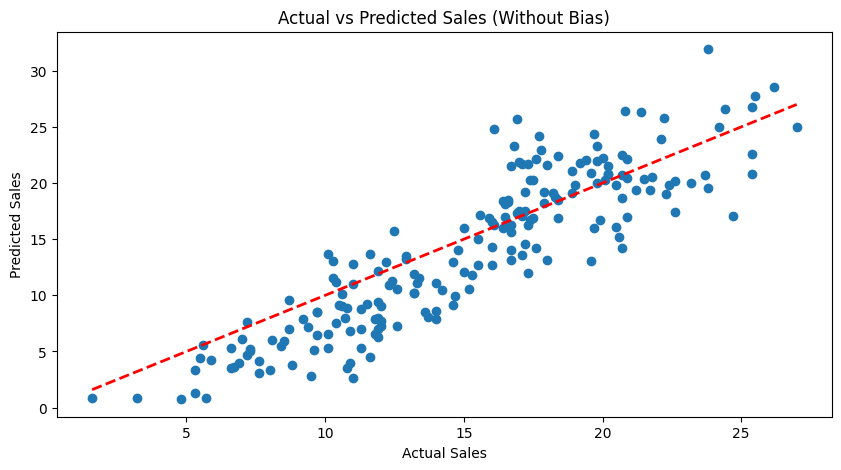

In [26]:
plt.figure(figsize=(10, 5))
plt.scatter(y_matrix, y_pred_matrix)
plt.plot([y_matrix.min(), y_matrix.max()], [y_matrix.min(), y_matrix.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Sales (Without Bias)')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()


**PART C**

##### With Bias (including B0)

**Todo 1:** Use matrix multiplication to calculate the coefficients of the linear regression model with bias


In [27]:
X_with_bias = np.column_stack([np.ones(len(X_matrix)), X_matrix])
coeffs_with_bias = np.linalg.inv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y_matrix

**Todo 2**:

Predict the sales values from the above coefficients calculated. <br>
Calculate Mean Absolute Error, Mean Squared Error, Root Mean Squared Error and R Squared Score with the predicted values to the actual values given in the csv.

In [28]:
y_pred_with_bias = X_with_bias @ coeffs_with_bias
mae_with_bias = mean_absolute_error(y_matrix, y_pred_with_bias)
mse_with_bias = mean_squared_error(y_matrix, y_pred_with_bias)
rmse_with_bias = np.sqrt(mse_with_bias)
r2_with_bias = r2_score(y_matrix, y_pred_with_bias)

**Todo 3**: Plot the Actual and Predicted values. Provide interpretations for the visualization

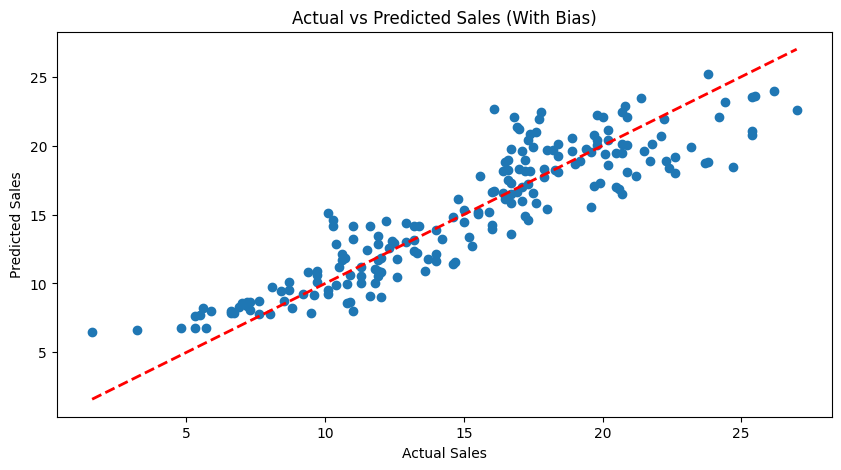

In [29]:
plt.figure(figsize=(10, 5))
plt.scatter(y_matrix, y_pred_with_bias)
plt.plot([y_matrix.min(), y_matrix.max()], [y_matrix.min(), y_matrix.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Sales (With Bias)')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()

**Todo 4**: Compare and interpret results of with and without bias.

In [30]:
print("Sklearn Model:", r2_sklearn)
print("Without Bias Model:", r2_matrix)
print("With Bias Model:", r2_with_bias)

Sklearn Model: 0.8236419280498489
Without Bias Model: 0.5767490187461874
With Bias Model: 0.8236419280498488


**Todo 5**: Do you notice any difference between the model evaluated with bias and sklearn model.

In [31]:
print("Sklearn Model:", r2_sklearn)
print("Without Bias Model:", r2_matrix)
print("With Bias Model:", r2_with_bias)

Sklearn Model: 0.8236419280498489
Without Bias Model: 0.5767490187461874
With Bias Model: 0.8236419280498488


#Problem 3 - Forward Selection - (25 Points)

Using the abalone csv file, implement the forward selection.

For performance evaluation, use adjusted R squared.

**Dataset:**
abalone.csv

**Attribute Information:**
Given is the attribute name, attribute type, the measurement unit, and a brief description.

Name / Data Type / Measurement Unit / Description

Length / continuous / mm / Longest shell measurement

Diameter / continuous / mm / perpendicular to length

Height / continuous / mm / with meat in shell

Whole weight / continuous / grams / whole abalone

Shucked weight / continuous / grams / weight of meat

Viscera weight / continuous / grams / gut weight (after bleeding)

Shell weight / continuous / grams / after being dried

Rings / integer / -- / +1.5 gives the age in years

**The target variable is Rings. The rest are predictors.**

**TODO 1:**
Load the csv file and split the data into train and test with 70:30 ratio.


In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load the data
df = pd.read_csv('abalone.csv')

# Separate features and target
X = df.drop('Rings', axis=1)
y = df['Rings']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

def calculate_adjusted_r_squared(X_train, X_test, y_train, y_test, columns):
    """
    Calculate adjusted R-squared for a subset of features
    """
    # Fit linear regression model
    model = LinearRegression()
    model.fit(X_train[columns], y_train)
    
    # Predict and calculate R-squared
    y_pred = model.predict(X_test[columns])
    r2 = r2_score(y_test, y_pred)
    
    # Calculate adjusted R-squared
    n = X_test.shape[0]
    p = len(columns)
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
    return adjusted_r2

**TODO 2:**
Choosing the first variable.

Write a function with inputs as variables, builds a linear regression model (use sklearn) and returns the adjusted R squared score.

1. From the 7 variables present, select one variable each time and build a linear regression model (using the above function that you have built).

2. Compare the model performance by adjusted R square. Present your results in a tabular form with vairable and the R squared value.

3. Select the winning model.

In [35]:
print("Step 1: Selecting the First Variable")
feature_performance = {}
for column in X.columns:
    feature_performance[column] = calculate_adjusted_r_squared(X_train, X_test, y_train, y_test, [column])

# Print results and find the best first variable
print("First Variable Performance:")
for feature, score in feature_performance.items():
    print(f"{feature}: {score}")

best_first_feature = max(feature_performance, key=feature_performance.get)
print(f"\nBest First Feature: {best_first_feature}")

Step 1: Selecting the First Variable
First Variable Performance:
Length: 0.32611226755196876
Diameter: 0.35164669192775655
Height: 0.3437567385015494
Whole weight: 0.3042616873642523
Shucked weight: 0.1884343445386033
Viscera weight: 0.2628309782155871
Shell weight: 0.3997184591762607

Best First Feature: Shell weight


**TODO 3:**
Choosing the second variable
1. Using the variable from the winning model, find the second best variable with the possible combinations.

2. compare the model performance and present your results in a tabular form.

3. select the winning model.

In [36]:
print("\nStep 2: Selecting the Second Variable")
second_variable_performance = {}
for column in X.columns:
    if column != best_first_feature:
        columns = [best_first_feature, column]
        second_variable_performance[column] = calculate_adjusted_r_squared(X_train, X_test, y_train, y_test, columns)

# Print results and find the best second variable
print("Second Variable Performance:")
for feature, score in second_variable_performance.items():
    print(f"{feature}: {score}")

best_second_feature = max(second_variable_performance, key=second_variable_performance.get)
print(f"\nBest Second Feature: {best_second_feature}")

# Combine the two best features
best_features = [best_first_feature, best_second_feature]
print("\nSelected Features:")
print(best_features)


Step 2: Selecting the Second Variable
Second Variable Performance:
Length: 0.3983439071166287
Diameter: 0.3995591187369595
Height: 0.4059024052931637
Whole weight: 0.4248368476434241
Shucked weight: 0.46384647866131634
Viscera weight: 0.42244592979975737

Best Second Feature: Shucked weight

Selected Features:
['Shell weight', 'Shucked weight']


**Todo 4:** What are the 2 variables selected